# GMM_codes.ipynb

本 notebook 是 `GMM_lec.qmd` 的配套“素材工厂”，主要负责两类任务：

- 生成讲义中要引用的图形
- 生成后续案例 notebook 要使用的模拟数据和本地备份数据

整体设计遵循两个原则：

- 每个代码 cell 前都用 Markdown 说明其用途、对应讲义章节和输出文件名
- 所有输出统一保存到 `./figs/` 和 `./data/`，便于讲义与案例 notebook 复用

说明：

- 本 notebook 不要求你逐段运行；你可以按图形或按数据模块选择执行
- 若本地缺少某些扩展包，例如 `pandas_datareader`，只会影响 FRED 数据备份模块，不影响其余部分


In [1]:
# ============================================================
# 0. 导入依赖包、创建文件夹、设置全局绘图风格
# ============================================================

import os
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm

warnings.filterwarnings('ignore')

# ------------------------------
# 创建输出目录
# ------------------------------
os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

# ------------------------------
# 颜色方案：与 MLE 章节保持一致
# ------------------------------
COLOR_PRIMARY   = '#2C6BAC'   # 主色：蓝色
COLOR_SECONDARY = '#E8A020'   # 辅色：橙黄色
COLOR_NEUTRAL   = '#888888'   # 中性：灰色
COLOR_FILL      = '#D6E8F7'   # 填充：淡蓝
COLOR_GREEN     = '#2CA02C'   # 绿色
COLOR_RED       = '#D62728'   # 红色
COLOR_PURPLE    = '#7F3C8D'   # 辅助紫色

# ------------------------------
# 中文字体检测：Windows 优先使用 SimHei
# Linux / macOS 则回退到常见中文字体
# ------------------------------
if platform.system() == 'Windows':
    FONT_FAMILY = 'SimHei'
else:
    import matplotlib.font_manager as fm
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    FONT_FAMILY = 'DejaVu Sans'
    for candidate in ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'Source Han Sans SC']:
        if candidate in available_fonts:
            FONT_FAMILY = candidate
            break

plt.rcParams['font.family'] = FONT_FAMILY
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'当前字体：{FONT_FAMILY}')
print('输出目录已创建：./figs, ./data')

# ------------------------------
# 一个通用的保存函数
# 统一控制 bbox 和 dpi，避免各图输出风格不一致
# ------------------------------
def savefig(fname):
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'已保存：{fname}')


当前字体：SimHei
输出目录已创建：./figs, ./data


## 图 01：GMM 总流程图

对应讲义：导言、第 1 节、第 10 节。  
输出文件：`./figs/method_GMM_fig01_flowchart.png`

本图是全章的“导航图”。思路上与 MLE 章节的流程图保持一致，但节点内容改成 GMM 的核心链条：样本数据 → 矩条件 → 样本矩偏离 → 加权目标函数 → 参数估计 → 推断与检验。


已保存：./figs/method_GMM_fig01_flowchart.png


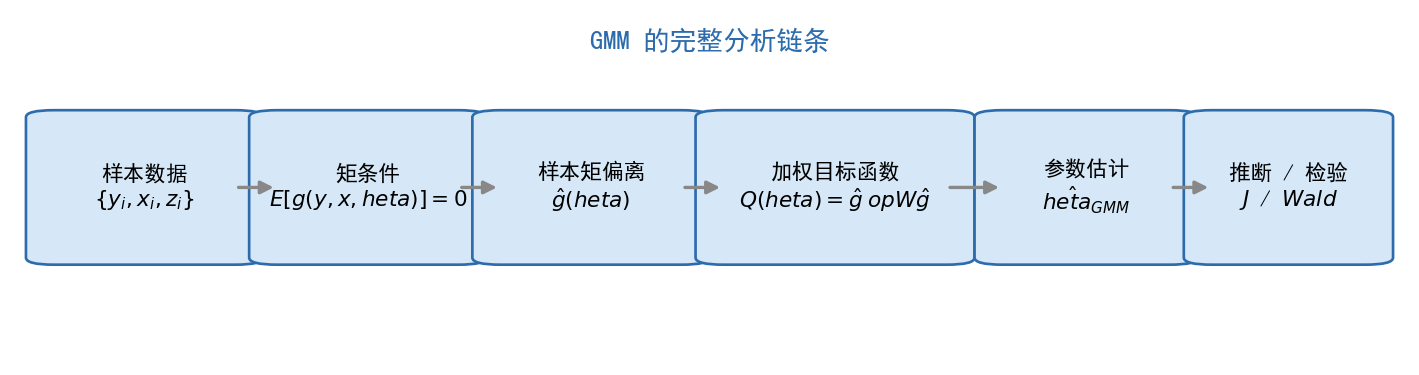

In [3]:
# ============================================================
# 1. 图 01：GMM 总流程图
# ============================================================

fig, ax = plt.subplots(figsize=(15, 3.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 六个流程节点
boxes = [
    (0.03, 0.30, 0.13, 0.40, '样本数据\n$\{y_i, x_i, z_i\}$'),
    (0.19, 0.30, 0.13, 0.40, '矩条件\n$E[g(y, x, \theta)] = 0$'),
    (0.35, 0.30, 0.13, 0.40, '样本矩偏离\n$\hat{g}(\theta)$'),
    (0.51, 0.30, 0.16, 0.40, '加权目标函数\n$Q(\theta) = \hat{g}^\top W \hat{g}$'),
    (0.71, 0.30, 0.12, 0.40, '参数估计\n$\hat{\theta}_{GMM}$'),
    (0.86, 0.30, 0.11, 0.40, '推断 / 检验\n$J$ / $Wald$'),
]

for x, y, w, h, label in boxes:
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        linewidth=1.6,
        edgecolor=COLOR_PRIMARY,
        facecolor=COLOR_FILL
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center', fontsize=13)

# 节点之间的箭头
for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + boxes[i][2]
    y1 = boxes[i][1] + boxes[i][3] / 2
    x2 = boxes[i+1][0]
    y2 = boxes[i+1][1] + boxes[i+1][3] / 2
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>',
        mutation_scale=16,
        linewidth=2.0,
        color=COLOR_NEUTRAL
    )
    ax.add_patch(arrow)

ax.text(0.5, 0.92, 'GMM 的完整分析链条', ha='center', va='center',
        fontsize=16, fontweight='bold', color=COLOR_PRIMARY)

savefig('./figs/method_GMM_fig01_flowchart.png')
plt.show()


## 图 02：矩条件示意图（恰好识别 vs. 过度识别）

对应讲义：第 2 节。  
输出文件：`./figs/method_GMM_fig02_moment_conditions.png`

左图展示单个矩条件时，样本矩条件与零线的交点就是估计量。右图展示多个矩条件的“零点”不再一致，于是需要通过加权折中来寻找最优参数。


已保存：./figs/method_GMM_fig02_moment_conditions.png


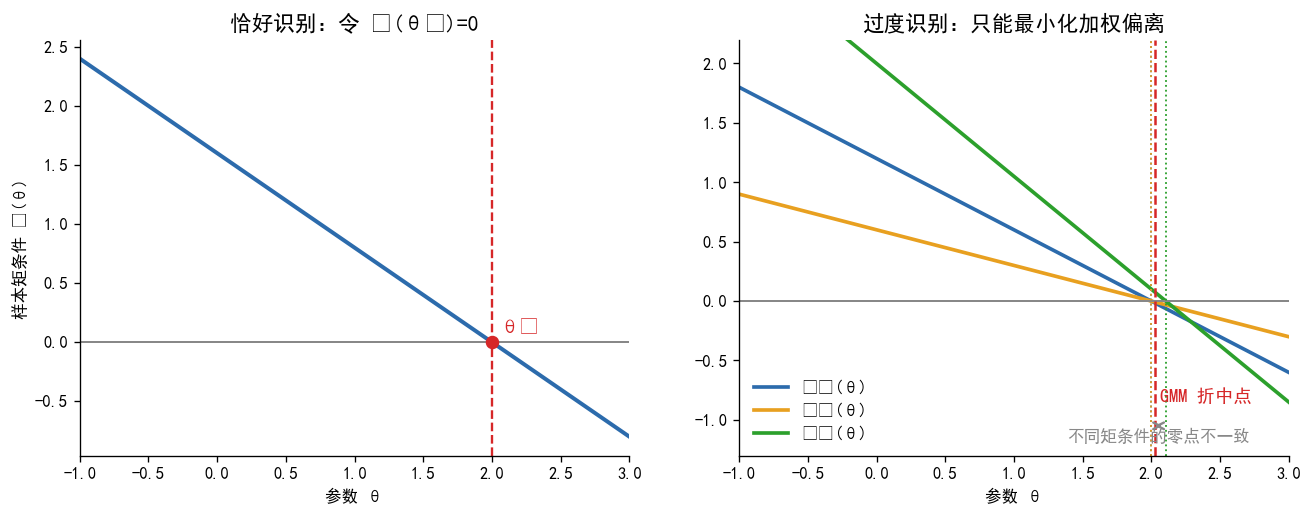

In [4]:
# ============================================================
# 2. 图 02：矩条件示意图（恰好识别 vs. 过度识别）
# ============================================================

theta = np.linspace(-1, 3, 400)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ------------------------------
# 左图：恰好识别
# ------------------------------
g1 = 1.6 - 0.8 * theta
theta_hat = 1.6 / 0.8

axes[0].plot(theta, g1, color=COLOR_PRIMARY, linewidth=2.4)
axes[0].axhline(0, color=COLOR_NEUTRAL, linewidth=1.2)
axes[0].axvline(theta_hat, color=COLOR_RED, linestyle='--', linewidth=1.4)
axes[0].scatter([theta_hat], [0], color=COLOR_RED, s=50, zorder=3)
axes[0].text(theta_hat + 0.05, 0.08, 'θ̂', color=COLOR_RED, fontsize=12)
axes[0].set_title('恰好识别：令 ĝ(θ̂)=0', fontsize=13)
axes[0].set_xlabel('参数 θ')
axes[0].set_ylabel('样本矩条件 ĝ(θ)')
axes[0].set_xlim(-1, 3)

# ------------------------------
# 右图：过度识别
# ------------------------------
g2_1 = 1.2 - 0.6 * theta
g2_2 = 0.6 - 0.3 * theta
g2_3 = 2.0 - 0.95 * theta

axes[1].plot(theta, g2_1, color=COLOR_PRIMARY, linewidth=2.2, label='ĝ₁(θ)')
axes[1].plot(theta, g2_2, color=COLOR_SECONDARY, linewidth=2.2, label='ĝ₂(θ)')
axes[1].plot(theta, g2_3, color=COLOR_GREEN, linewidth=2.2, label='ĝ₃(θ)')
axes[1].axhline(0, color=COLOR_NEUTRAL, linewidth=1.2)

zero_points = [1.2/0.6, 0.6/0.3, 2.0/0.95]
for zp, c in zip(zero_points, [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_GREEN]):
    axes[1].axvline(zp, color=c, linestyle=':', linewidth=1.1)

# 用一个“折中点”表示 GMM 解
theta_gmm = np.average(zero_points, weights=[2.5, 1.6, 1.2])
axes[1].axvline(theta_gmm, color=COLOR_RED, linestyle='--', linewidth=1.5)
axes[1].text(theta_gmm + 0.04, -0.85, 'GMM 折中点', color=COLOR_RED, fontsize=11)

# 双向箭头：标注零点不一致
axes[1].annotate(
    '', xy=(zero_points[0], -1.05), xytext=(zero_points[2], -1.05),
    arrowprops=dict(arrowstyle='<->', color=COLOR_NEUTRAL, lw=1.4)
)
axes[1].text(np.mean([zero_points[0], zero_points[2]]), -1.18, '不同矩条件的零点不一致',
             ha='center', color=COLOR_NEUTRAL, fontsize=10)

axes[1].set_title('过度识别：只能最小化加权偏离', fontsize=13)
axes[1].set_xlabel('参数 θ')
axes[1].set_xlim(-1, 3)
axes[1].set_ylim(-1.3, 2.2)
axes[1].legend(frameon=False, fontsize=10)

savefig('./figs/method_GMM_fig02_moment_conditions.png')
plt.show()


## 图 03：不同权重矩阵下的 GMM 目标函数

对应讲义：第 3 节。  
输出文件：`./figs/method_GMM_fig03_gmm_objective.png`

本图通过一个非常简单的二矩条件例子，展示权重矩阵改变后，目标函数曲线和最优解位置如何变化。


已保存：./figs/method_GMM_fig03_gmm_objective.png


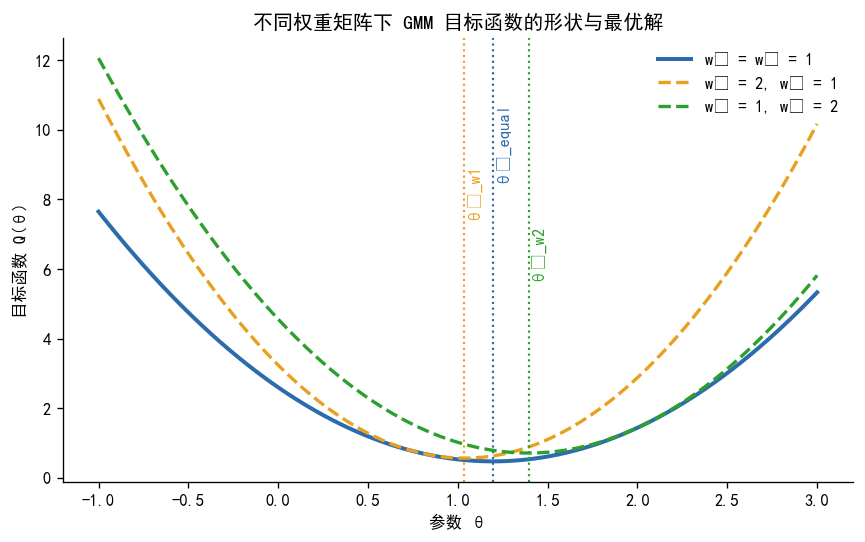

In [5]:
# ============================================================
# 3. 图 03：不同权重矩阵下的 GMM 目标函数
# ============================================================

theta = np.linspace(-1, 3, 600)

# 两条矩条件的“零点”故意设置为不同
a1, b1 = 1.0, 0.8
a2, b2 = 0.7, 1.4

g1 = a1 * theta - b1
g2 = a2 * theta - b2

def Q(theta_vec, w1, w2):
    return (a1 * theta_vec - b1) ** 2 * w1 + (a2 * theta_vec - b2) ** 2 * w2

Q_equal = Q(theta, 1, 1)
Q_w1big = Q(theta, 2, 1)
Q_w2big = Q(theta, 1, 2)

# 解析最优解：对一元二次函数求导即可
def theta_star(w1, w2):
    num = w1 * a1 * b1 + w2 * a2 * b2
    den = w1 * a1**2 + w2 * a2**2
    return num / den

th_equal = theta_star(1, 1)
th_w1big = theta_star(2, 1)
th_w2big = theta_star(1, 2)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(theta, Q_equal, color=COLOR_PRIMARY, linewidth=2.4, label='w₁ = w₂ = 1')
ax.plot(theta, Q_w1big, color=COLOR_SECONDARY, linewidth=2.0, linestyle='--', label='w₁ = 2, w₂ = 1')
ax.plot(theta, Q_w2big, color=COLOR_GREEN, linewidth=2.0, linestyle='--', label='w₁ = 1, w₂ = 2')

ax.axvline(th_equal, color=COLOR_PRIMARY, linestyle=':', linewidth=1.3)
ax.axvline(th_w1big, color=COLOR_SECONDARY, linestyle=':', linewidth=1.3)
ax.axvline(th_w2big, color=COLOR_GREEN, linestyle=':', linewidth=1.3)

ax.text(th_equal, ax.get_ylim()[1]*0.86, 'θ̂_equal', color=COLOR_PRIMARY, rotation=90, va='top')
ax.text(th_w1big, ax.get_ylim()[1]*0.72, 'θ̂_w1', color=COLOR_SECONDARY, rotation=90, va='top')
ax.text(th_w2big, ax.get_ylim()[1]*0.58, 'θ̂_w2', color=COLOR_GREEN, rotation=90, va='top')

ax.set_xlabel('参数 θ')
ax.set_ylabel('目标函数 Q(θ)')
ax.set_title('不同权重矩阵下 GMM 目标函数的形状与最优解')
ax.legend(frameon=False)

savefig('./figs/method_GMM_fig03_gmm_objective.png')
plt.show()


## 图 04：不同估计量的有限样本分布对比

对应讲义：第 6 节。  
输出文件：`./figs/method_GMM_fig04_efficiency.png`

该图通过 Monte Carlo 模拟比较三种估计量在异方差情形下的抽样分布：

- 2SLS
- 等权 GMM（`W = I`）
- 有效两步 GMM（`W = Ŝ^{-1}`）

图形目标是展示一个常见结论：在异方差场景下，有效 GMM 的分布通常更集中。


In [6]:
# ============================================================
# 4. 图 04：Monte Carlo 对比 2SLS、等权 GMM、有效 GMM
# ============================================================

np.random.seed(2024)

def iv_2sls_estimate(y, x, Z):
    # ------------------------------
    # 一元内生变量的 2SLS 闭式表达
    # x 为 n×1，Z 为 n×q
    # ------------------------------
    Pz = Z @ np.linalg.inv(Z.T @ Z) @ Z.T
    beta_hat = np.linalg.inv(x.T @ Pz @ x) @ (x.T @ Pz @ y)
    return float(beta_hat)

def iv_gmm_estimate(y, x, Z, W):
    # ------------------------------
    # 一元线性 GMM 的闭式解
    # beta = (X'ZWZ'X)^(-1) X'ZWZ'Y
    # ------------------------------
    beta_hat = np.linalg.inv(x.T @ Z @ W @ Z.T @ x) @ (x.T @ Z @ W @ Z.T @ y)
    return float(beta_hat)

def compute_S_hat_linear(y, x, Z, beta_hat):
    # ------------------------------
    # 线性 IV-GMM 下的样本矩方差矩阵
    # g_i = z_i * e_i
    # 这里使用异方差稳健版本
    # ------------------------------
    e = (y - x.flatten() * beta_hat).reshape(-1, 1)
    g_each = Z * e
    g_dm = g_each - g_each.mean(axis=0, keepdims=True)
    S_hat = g_dm.T @ g_dm / len(y)
    return S_hat

R = 1000
n = 200
beta_true = 1.0

b_2sls = []
b_gmm_equal = []
b_gmm_opt = []

for r in range(R):
    # 工具变量
    z1 = np.random.normal(0, 1, n)
    z2 = np.random.normal(0, 1, n)
    z3 = np.random.normal(0, 1, n)
    Z  = np.column_stack([z1, z2, z3])

    # 内生变量：由工具变量和 v 共同生成
    v = np.random.normal(0, 1, n)
    x = 0.5 * z1 + 0.4 * z2 + 0.3 * z3 + v

    # 异方差误差项，并通过 v 让 x 与结构误差相关
    e0 = np.random.normal(0, 1, n)
    sigma = 0.5 + 0.5 * np.abs(x)
    eps = sigma * e0 + 0.35 * v

    y = beta_true * x + eps
    y = y.reshape(-1, 1)
    x = x.reshape(-1, 1)

    # 2SLS
    b2 = iv_2sls_estimate(y, x, Z)
    b_2sls.append(b2)

    # 等权 GMM：W = I
    W_equal = np.eye(Z.shape[1])
    bg_eq = iv_gmm_estimate(y, x, Z, W_equal)
    b_gmm_equal.append(bg_eq)

    # 两步有效 GMM
    S_hat = compute_S_hat_linear(y, x, Z, bg_eq)
    W_opt = np.linalg.pinv(S_hat)
    bg_opt = iv_gmm_estimate(y, x, Z, W_opt)
    b_gmm_opt.append(bg_opt)

b_2sls = np.array(b_2sls)
b_gmm_equal = np.array(b_gmm_equal)
b_gmm_opt = np.array(b_gmm_opt)

# 使用 scipy 的 gaussian_kde 绘制平滑密度
grid = np.linspace(0.55, 1.45, 500)
kde_2sls = stats.gaussian_kde(b_2sls)
kde_eq   = stats.gaussian_kde(b_gmm_equal)
kde_opt  = stats.gaussian_kde(b_gmm_opt)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(grid, kde_2sls(grid), color=COLOR_RED, linewidth=2.2,
        label=f'2SLS  (Std = {b_2sls.std(ddof=1):.4f})')
ax.plot(grid, kde_eq(grid), color=COLOR_SECONDARY, linewidth=2.2,
        label=f'GMM-equal  (Std = {b_gmm_equal.std(ddof=1):.4f})')
ax.plot(grid, kde_opt(grid), color=COLOR_PRIMARY, linewidth=2.4,
        label=f'GMM-opt  (Std = {b_gmm_opt.std(ddof=1):.4f})')

ax.axvline(beta_true, color=COLOR_NEUTRAL, linestyle='--', linewidth=1.4, label='真实值 β = 1')
ax.set_xlabel('估计值 β̂')
ax.set_ylabel('核密度')
ax.set_title('异方差场景下三种估计量的蒙特卡洛分布')
ax.legend(frameon=False)

savefig('./figs/method_GMM_fig04_efficiency.png')
plt.show()

print('标准差对比：')
print(f'2SLS        : {b_2sls.std(ddof=1):.4f}')
print(f'GMM-equal   : {b_gmm_equal.std(ddof=1):.4f}')
print(f'GMM-opt     : {b_gmm_opt.std(ddof=1):.4f}')


TypeError: only 0-dimensional arrays can be converted to Python scalars

## 图 05：2SLS 与 GMM 权重机制对比示意图

对应讲义：第 4 节。  
输出文件：`./figs/method_GMM_fig05_2sls_vs_gmm.png`

左栏强调 2SLS 的“先合成一个拟合值，再进入第二阶段”思路；右栏强调 GMM 的“保留多条矩条件，并按方差-协方差结构差异化加权”思路。


In [7]:
# ============================================================
# 5. 图 05：2SLS vs. GMM 权重机制示意图
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

# ------------------------------
# 左栏：2SLS
# ------------------------------
ax = axes[0]
ax.set_title('2SLS：等权合并', fontsize=14, color=COLOR_PRIMARY)

nodes_left = {
    'z1': (0.10, 0.75, 'z₁'),
    'z2': (0.10, 0.50, 'z₂'),
    'z3': (0.10, 0.25, 'z₃'),
    'xh': (0.50, 0.50, 'x̂
第一阶段拟合值'),
    'b2': (0.83, 0.50, 'β̂₂SLS'),
}

for key, (x, y, txt) in nodes_left.items():
    patch = FancyBboxPatch(
        (x-0.08, y-0.08), 0.16, 0.16,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        facecolor=COLOR_FILL,
        edgecolor=COLOR_PRIMARY,
        linewidth=1.5
    )
    ax.add_patch(patch)
    ax.text(x, y, txt, ha='center', va='center', fontsize=12)

for start in ['z1', 'z2', 'z3']:
    x1, y1, _ = nodes_left[start]
    x2, y2, _ = nodes_left['xh']
    ax.add_patch(FancyArrowPatch((x1+0.08, y1), (x2-0.08, y2),
                                 arrowstyle='-|>', mutation_scale=14,
                                 linewidth=2.0, color=COLOR_NEUTRAL))
x1, y1, _ = nodes_left['xh']
x2, y2, _ = nodes_left['b2']
ax.add_patch(FancyArrowPatch((x1+0.08, y1), (x2-0.08, y2),
                             arrowstyle='-|>', mutation_scale=14,
                             linewidth=2.2, color=COLOR_NEUTRAL))

# ------------------------------
# 右栏：有效 GMM
# ------------------------------
ax = axes[1]
ax.set_title('有效 GMM：差异化加权', fontsize=14, color=COLOR_PRIMARY)

nodes_right = {
    'g1': (0.10, 0.75, 'ĝ₁'),
    'g2': (0.10, 0.50, 'ĝ₂'),
    'g3': (0.10, 0.25, 'ĝ₃'),
    'Q':  (0.52, 0.50, 'Q = ĝᵀWĝ'),
    'bg': (0.84, 0.50, 'β̂_GMM'),
}

for key, (x, y, txt) in nodes_right.items():
    patch = FancyBboxPatch(
        (x-0.09, y-0.08), 0.18, 0.16,
        boxstyle='round,pad=0.02,rounding_size=0.02',
        facecolor=COLOR_FILL if key != 'Q' else '#FFF4D6',
        edgecolor=COLOR_PRIMARY if key != 'Q' else COLOR_SECONDARY,
        linewidth=1.5
    )
    ax.add_patch(patch)
    ax.text(x, y, txt, ha='center', va='center', fontsize=12)

weights = [('g1', 3.2, 3.2), ('g2', 2.1, 2.3), ('g3', 0.8, 1.0)]
for name, wval, lw in weights:
    x1, y1, _ = nodes_right[name]
    x2, y2, _ = nodes_right['Q']
    ax.add_patch(FancyArrowPatch((x1+0.09, y1), (x2-0.10, y2),
                                 arrowstyle='-|>', mutation_scale=14,
                                 linewidth=lw, color=COLOR_NEUTRAL))
    ax.text((x1+x2)/2-0.03, (y1+y2)/2 + 0.05, f'w = {wval}', fontsize=10, color=COLOR_NEUTRAL)

x1, y1, _ = nodes_right['Q']
x2, y2, _ = nodes_right['bg']
ax.add_patch(FancyArrowPatch((x1+0.09, y1), (x2-0.09, y2),
                             arrowstyle='-|>', mutation_scale=14,
                             linewidth=2.2, color=COLOR_NEUTRAL))

savefig('./figs/method_GMM_fig05_2sls_vs_gmm.png')
plt.show()


SyntaxError: unterminated string literal (detected at line 21) (274247378.py, line 21)

## 数据 01：过度识别 IV + 异方差

对应案例：`GMM_case.ipynb` Case 1。  
输出文件：`./data/method_GMM_data01_iv_hetero.csv`

这里专门保留了若干“教学辅助变量”，例如 `eps` 与 `sigma`，便于在案例 notebook 中直接画出异方差特征，而不必额外反推。


In [8]:
# ============================================================
# 6. 数据 01：过度识别 IV + 异方差
# ============================================================

np.random.seed(2024)
n = 500

# 工具变量
z1 = np.random.normal(0, 1, n)
z2 = np.random.normal(0, 1, n)
z3 = np.random.normal(0, 1, n)
z4 = np.random.normal(0, 1, n)   # 额外引入一个更弱的工具变量

# 内生变量的“扰动部分”
v = np.random.normal(0, 1, n)

# 内生变量 x 由工具变量和 v 共同决定
x = 0.5 * z1 + 0.4 * z2 + 0.3 * z3 + 0.15 * z4 + v

# 误差项：先构造异方差，再叠加与 v 相关的部分以制造内生性
e0 = np.random.normal(0, 1, n)
sigma = 0.5 + 0.5 * np.abs(x)
eps = sigma * e0 + 0.4 * v

# 因变量
y = 1 + 1.5 * x + eps

df1 = pd.DataFrame({
    'y': y,
    'x': x,
    'z1': z1,
    'z2': z2,
    'z3': z3,
    'z4': z4,
    'v': v,
    'sigma': sigma,
    'eps': eps
})

df1.to_csv('./data/method_GMM_data01_iv_hetero.csv', index=False)
print(df1.head())
print(df1.describe().round(4))
print('已保存：./data/method_GMM_data01_iv_hetero.csv')


          y         x        z1        z2        z3        z4         v  \
0  1.265961  0.503948  1.668047 -1.647301  1.391511 -0.924969  0.050137   
1 -1.033467 -0.109778  0.737348  0.178941  0.155730  0.189044 -0.625103   
2  5.877642  1.369030 -0.201538  0.120101 -0.432998 -0.118728  1.569467   
3  1.632071  0.684830 -0.150912  1.731161 -0.674284 -1.445949  0.487000   
4  4.806162  2.161554  0.916052  1.341363  0.255122 -1.796155  1.359870   

      sigma       eps  
0  0.751974 -0.489961  
1  0.554889 -1.868800  
2  1.184515  2.824097  
3  0.842415 -0.395175  
4  1.580777  0.563831  
              y         x        z1        z2        z3        z4         v  \
count  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000  500.0000   
mean     1.1134    0.0429   -0.0263    0.0743   -0.0497   -0.0146    0.0434   
std      2.5144    1.2696    1.0583    0.9688    1.0165    1.0347    1.0192   
min     -7.3917   -3.2472   -3.4207   -3.6729   -2.9039   -2.6677   -3.1683   
25%     -0

## 数据 02：Euler 方程模拟数据

对应案例：`GMM_case.ipynb` Case 2a。  
输出文件：`./data/method_GMM_data02_euler_simulated.csv`

设计思路：

- 先给定真实参数 `beta_true = 0.98` 与 `gamma_true = 2.0`
- 再生成消费增长率 `dc = c_{t+1} / c_t`
- 之后根据 Euler 方程的均衡条件构造收益率 `R`
- 最后加入工具变量所需的滞后项


In [9]:
# ============================================================
# 7. 数据 02：Euler 方程模拟数据
# ============================================================

np.random.seed(2024)
T = 200

beta_true = 0.98
gamma_true = 2.0

# 对数消费增长率：均值略大于 0，波动适中
log_dc = np.random.normal(0.005, 0.02, T)
dc = np.exp(log_dc)

# 由 Euler 方程近似反推收益率，再叠加噪声
R_mean = 1 / (beta_true * dc ** (-gamma_true))
R = R_mean * np.exp(np.random.normal(0, 0.05, T))

# 生成工具变量需要的滞后项
dc_lag1 = np.roll(dc, 1); dc_lag1[0] = np.nan
dc_lag2 = np.roll(dc, 2); dc_lag2[:2] = np.nan
R_lag1 = np.roll(R, 1);   R_lag1[0] = np.nan
R_lag2 = np.roll(R, 2);   R_lag2[:2] = np.nan

df2 = pd.DataFrame({
    'dc': dc,
    'R': R,
    'dc_lag1': dc_lag1,
    'dc_lag2': dc_lag2,
    'R_lag1': R_lag1,
    'R_lag2': R_lag2,
})

df2 = df2.dropna().reset_index(drop=True)
df2.to_csv('./data/method_GMM_data02_euler_simulated.csv', index=False)

print(f'真实参数：beta = {beta_true}, gamma = {gamma_true}')
print(df2.head())
print(df2.describe().round(4))
print('已保存：./data/method_GMM_data02_euler_simulated.csv')


真实参数：beta = 0.98, gamma = 2.0
         dc         R   dc_lag1   dc_lag2    R_lag1    R_lag2
0  1.000970  1.008576  1.019943  1.039106  1.179340  1.162359
1  1.001984  1.040980  1.000970  1.019943  1.008576  1.179340
2  1.023595  1.046585  1.001984  1.000970  1.040980  1.008576
3  1.028608  1.134790  1.023595  1.001984  1.046585  1.040980
4  0.953707  0.980073  1.028608  1.023595  1.134790  1.046585
             dc         R   dc_lag1   dc_lag2    R_lag1    R_lag2
count  198.0000  198.0000  198.0000  198.0000  198.0000  198.0000
mean     1.0061    1.0270    1.0064    1.0067    1.0282    1.0289
std      0.0204    0.0670    0.0201    0.0202    0.0675    0.0682
min      0.9537    0.8275    0.9537    0.9537    0.8275    0.8275
25%      0.9937    0.9813    0.9941    0.9941    0.9850    0.9850
50%      1.0058    1.0239    1.0060    1.0061    1.0245    1.0251
75%      1.0200    1.0695    1.0202    1.0211    1.0709    1.0713
max      1.0608    1.1830    1.0608    1.0608    1.1830    1.1830
已保存：

## 数据 03：横截面资产定价模拟数据

对应案例：`GMM_case.ipynb` Case 3。  
输出文件：`./data/method_GMM_data03_asset_pricing.csv`

这里模拟 25 个资产组合在 60 期上的超额收益率，并允许截面误差相关，以便在案例 notebook 中比较 Fama-MacBeth 与多方程 GMM。


In [10]:
# ============================================================
# 8. 数据 03：横截面资产定价模拟数据
# ============================================================

np.random.seed(2024)
N = 25
T = 60

# 市场超额收益率
mkt_excess = np.random.normal(0.006, 0.04, T)

# 资产 beta 从 0.5 到 1.5 均匀变化
betas = np.linspace(0.5, 1.5, N)

# 构造带有截面相关的误差协方差矩阵
cov_matrix = np.ones((N, N)) * 0.3 + np.eye(N) * 0.7
cov_matrix *= 0.02 ** 2

eps_panel = np.random.multivariate_normal(np.zeros(N), cov_matrix, T)

excess_returns = np.zeros((T, N))
for i in range(N):
    alpha_i = 0.001 * np.random.randn()
    excess_returns[:, i] = alpha_i + betas[i] * mkt_excess + eps_panel[:, i]

rows = []
for t in range(T):
    for i in range(N):
        rows.append({
            'time': t,
            'asset': i,
            'excess_ret': excess_returns[t, i],
            'mkt_excess': mkt_excess[t],
            'beta_true': betas[i]
        })

df3 = pd.DataFrame(rows)
df3.to_csv('./data/method_GMM_data03_asset_pricing.csv', index=False)

print(df3.head(10).round(4))
print(f'数据维度：{df3.shape}')
print('已保存：./data/method_GMM_data03_asset_pricing.csv')


   time  asset  excess_ret  mkt_excess  beta_true
0     0      0      0.0295      0.0727     0.5000
1     0      1      0.0215      0.0727     0.5417
2     0      2      0.0491      0.0727     0.5833
3     0      3      0.0543      0.0727     0.6250
4     0      4      0.0330      0.0727     0.6667
5     0      5      0.0516      0.0727     0.7083
6     0      6      0.0167      0.0727     0.7500
7     0      7      0.0114      0.0727     0.7917
8     0      8      0.0292      0.0727     0.8333
9     0      9      0.0364      0.0727     0.8750
数据维度：(1500, 5)
已保存：./data/method_GMM_data03_asset_pricing.csv


## 数据 04：FRED 真实数据备份（可选）

对应案例：`GMM_case.ipynb` Case 2b。  
输出文件：`./data/method_GMM_data04_euler_FRED.csv`

若本地网络允许，可直接从 FRED 下载；若下载失败，则不影响其余模块。你也可以把已有备份文件手动放到 `./data/` 目录。


In [11]:
# ============================================================
# 9. 数据 04：FRED 下载与本地备份
# ============================================================

try:
    import pandas_datareader.data as web
    from datetime import datetime

    start = datetime(1960, 1, 1)
    end = datetime(2019, 12, 31)

    # 个人消费支出增长率（季度）
    pce = web.DataReader('DPCERAS1Q086SBEA', 'fred', start, end)
    pce.columns = ['pce_growth']
    pce.index = pd.to_datetime(pce.index)
    pce = pce.resample('Q').last()

    # 标普 500 季度收益率
    sp500 = web.DataReader('SP500', 'fred', start, end)
    sp500 = sp500.resample('Q').last().pct_change().dropna()
    sp500.columns = ['sp500_ret']

    # 三月期国债利率，转换为季度收益率
    tbill = web.DataReader('TB3MS', 'fred', start, end)
    tbill = tbill.resample('Q').last() / 400
    tbill.columns = ['rf']

    df4 = pd.concat([pce, sp500, tbill], axis=1).dropna()
    df4['excess_ret'] = df4['sp500_ret'] - df4['rf']
    df4 = df4.reset_index().rename(columns={'DATE': 'date'})
    df4.to_csv('./data/method_GMM_data04_euler_FRED.csv', index=False)

    print(df4.head())
    print(df4.describe().round(4))
    print('已保存：./data/method_GMM_data04_euler_FRED.csv')

except Exception as e:
    print('FRED 数据下载失败。')
    print('这不会影响其余图形和模拟数据模块。')
    print(f'错误信息：{e}')
    print('如需 Case 2b，可手动准备本地备份文件 ./data/method_GMM_data04_euler_FRED.csv')


FRED 数据下载失败。
这不会影响其余图形和模拟数据模块。
错误信息：No module named 'pandas_datareader'
如需 Case 2b，可手动准备本地备份文件 ./data/method_GMM_data04_euler_FRED.csv
